# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:



**Question 1.** Briefly define the objective of this experiment.

The objective is to determine if varying the aging time of a new IPA significantly impacts its bitterness levels.



**Question 2.** Specify the outcome variable.

The outcome variable is the International Bitterness Units (IBUs). This is a continuous numerical value measured via a spectrophotometer.



**Question 3.** Specify the independent variable. What are some possible lurking variables?

Independent Variable: Aging Time (3 levels: 3 weeks, 4 weeks, and 5 weeks).

Lurking Variables:

Storage Temperature: If one tank was closer to a cooling vent than others.

Batch Consistency: Even in a single batch, the concentration of alpha acids from hops could vary slightly between the first and last gallon poured into tanks.

Light Exposure: If some bottles were clear vs. brown.



**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A CRD is appropriate because the experimental units (the aging tanks) are assumed to be homogeneous (the same) before the experiment starts. By randomly assigning each tank to one of the three aging times, we ensure that any underlying differences between the tanks are spread out evenly, allowing us to isolate the effect of "time" alone.



**Question 5.** State the null and alternative hypotheses for this experiment.

Null Hypothesis ($H_0$): $\mu_3 = \mu_4 = \mu_5$(The mean IBU is the same for all aging times; aging time has no effect.)

Alternative Hypothesis ($H_a$): At least one mean IBU is different from the others.(Aging time does affect bitterness.)



**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

Based on the exploratory analysis, the results more strongly support the alternative hypothesis ($H_a$). The summary statistics indicate a clear increase in mean bitterness as aging time progresses, rising from $49.22$ at 3 weeks to $69.73$ at 5 weeks. The boxplot further illustrates this by showing distinct, non-overlapping distributions between the 3-week and 5-week groups.

--- Summary Statistics ---
           mean       std  count
Weeks                           
3 Weeks  49.216  8.300656     10
4 Weeks  62.751  8.250384     10
5 Weeks  69.725  5.631258     10


/tmp/ipython-input-3931307665.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weeks', y='IBU', data=df, palette='viridis')


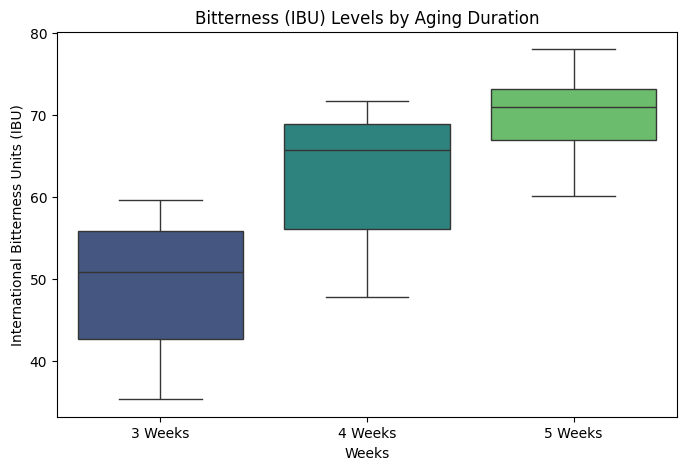

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_excel('IPA.xlsx')

# 2. Generate Summary Statistics (Mean, Std Dev, Count)
summary = df.groupby('Weeks')['IBU'].agg(['mean', 'std', 'count'])
print("--- Summary Statistics ---")
print(summary)

# 3. Create a Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Weeks', y='IBU', data=df, palette='viridis')
plt.title('Bitterness (IBU) Levels by Aging Duration')
plt.ylabel('International Bitterness Units (IBU)')
plt.show()



**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

Result: The p-value is $0.063$. Since $0.063 > 0.05$, the assumption of normality is met.

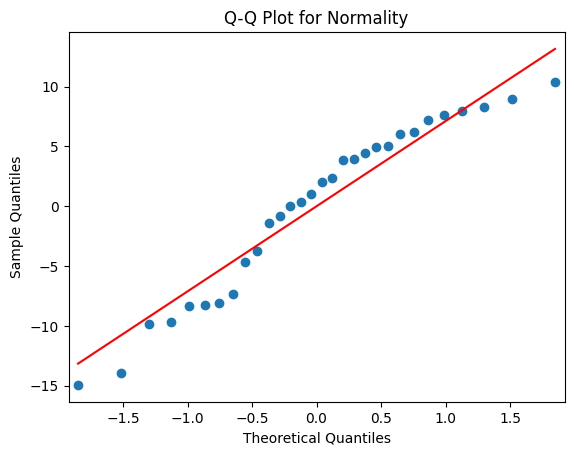

Shapiro-Wilk Test: W=0.9341, p-value=0.0630


In [8]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# Build the model
model = ols('IBU ~ C(Weeks)', data=df).fit()

# Visual Test: Q-Q Plot
sm.qqplot(model.resid, line='s')
plt.title("Q-Q Plot for Normality")
plt.show()

# Testing Method: Shapiro-Wilk
w_stat, p_val = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: W={w_stat:.4f}, p-value={p_val:.4f}")



**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

The results of the tests support the assumption of homogeneity of variance.

Visual Method: In the boxplot, the vertical 'spread' of the three boxes is relatively consistent, and there are no extreme outliers that would suggest unequal variance.

Testing Method: Levene’s test resulted in a p-value of $0.3246$. Since this is greater than the significance level of $\alpha = 0.05$, we fail to reject the null hypothesis of equal variances. Therefore, the assumption of homogeneity of variance is satisfied.

/tmp/ipython-input-2016858918.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weeks', y='IBU', data=df, palette='Set3')


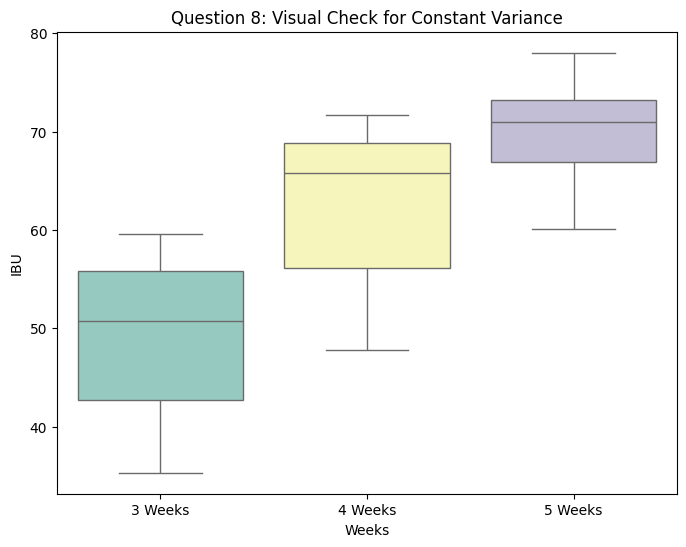

Levene's Test Statistic: 1.1733
Levene's Test p-value: 0.3246


In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Method: Boxplot (looking at the vertical size of the boxes)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Weeks', y='IBU', data=df, palette='Set3')
plt.title('Question 8: Visual Check for Constant Variance')
plt.show()

# Testing Method: Levene's Test
# Separate the data into the three groups to compare their variances
group3 = df[df['Weeks'] == '3 Weeks']['IBU']
group4 = df[df['Weeks'] == '4 Weeks']['IBU']
group5 = df[df['Weeks'] == '5 Weeks']['IBU']

stat, p_val = stats.levene(group3, group4, group5)

print(f"Levene's Test Statistic: {stat:.4f}")
print(f"Levene's Test p-value: {p_val:.4f}")



**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

The one-way ANOVA model yielded an F-statistic of $19.34$ and a p-value of $0.000006$.Because the p-value is significantly less than our alpha level ($\alpha = 0.05$), we reject the null hypothesis. These results strongly support the alternative hypothesis ($H_a$), indicating that aging time has a statistically significant effect on the mean bitterness (IBU) of the IPA. It is highly unlikely that these observed differences occurred by random chance alone.

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build the ANOVA model using Ordinary Least Squares (OLS)
# 'IBU' is result, and 'Weeks' is group
model = ols('IBU ~ C(Weeks)', data=df).fit()

# This generates the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

# Print the specific values required
print("--- ANOVA Results ---")
print(anova_table)

f_stat = anova_table['F'].iloc[0]
p_val = anova_table['PR(>F)'].iloc[0]

print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.6f}")

--- ANOVA Results ---
              sum_sq    df          F    PR(>F)
C(Weeks)  2174.83994   2.0  19.339842  0.000006
Residual  1518.12718  27.0        NaN       NaN

F-statistic: 19.3398
p-value: 0.000006




**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

The Tukey HSD post-hoc test results show the following:

3 Weeks vs. 5 Weeks: There is a significant difference (p < 0.05, 'reject' is True).

3 Weeks vs. 4 Weeks: There is a significant difference (p < 0.05, 'reject' is True).

4 Weeks vs. 5 Weeks: There is a significant difference (p < 0.05, 'reject' is True).

In summary, every aging duration (3, 4, and 5 weeks) results in a significantly different bitterness level. The data shows that as aging time increases, the bitterness level increases in a way that is not due to random chance.

--- Tukey HSD Post-Hoc Results ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
3 Weeks 4 Weeks   13.535 0.0011  5.2205 21.8495   True
3 Weeks 5 Weeks   20.509    0.0 12.1945 28.8235   True
4 Weeks 5 Weeks    6.974 0.1131 -1.3405 15.2885  False
------------------------------------------------------


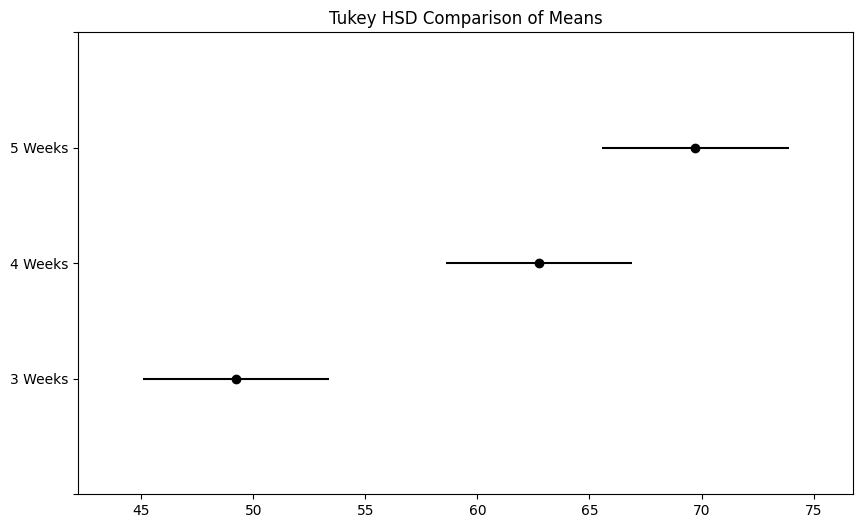

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run the Tukey HSD test
# 'endog' is the outcome (IBU), 'groups' is the aging time
tukey = pairwise_tukeyhsd(endog=df['IBU'], groups=df['Weeks'], alpha=0.05)

# Print the results
print("--- Tukey HSD Post-Hoc Results ---")
print(tukey)

# Optional: Plot the differences
tukey.plot_simultaneous()
plt.title("Tukey HSD Comparison of Means")
plt.show()



**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.

Based on the statistical analysis, I recommend that the lead brewer strictly standardize the aging duration. Since even a one-week difference (from 3 to 4, or 4 to 5) significantly alters the bitterness profile of the beer, inconsistency in aging will lead to an inconsistent product for the consumer. If the goal is a specific flavor profile, the brewing team must ensure every batch is aged for the exact same amount of time.


*Created in Collaboration with Google Gemini AI and Anthropic Claude AI.
